# Deep Learning Model Evaluation

Notebook ini mendemonstrasikan proses pelatihan dan evaluasi model klasifikasi sentimen menggunakan Deep Learning (Arsitektur LSTM). Model dievaluasi menggunakan *data uji (test set)* yang disembunyikan (*unseen data*) dari fase pelatihan untuk memverifikasi kemampuan generalisasinya.

Tahapan:
1. Data Loading & Preprocessing
2. Train-Test Split (Data Latih & Uji)
3. LSTM Model Architecture
4. Training with Class Weights & Optimizer Scheduling
5. Evaluation (Akurasi, F1, Confusion Matrix, Classification Report)


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Preprocessing

In [2]:
df = pd.read_csv('../data/data_preprocessed.csv')
print(f'Original data shape: {df.shape}')
df = df.dropna(subset=['text_processed', 'sentiment', 'label'])

# Mapping
label_map = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
if 'sentiment' in df.columns and ('label' not in df.columns or df['label'].dtype == 'object'):
    df['dl_label'] = df['sentiment'].map(label_map)
else:
    df['dl_label'] = df['label']

texts = df['text_processed'].astype(str).values
labels = df['dl_label'].astype(int).values

print(f"Distribusi label:\n{df['sentiment'].value_counts()}")


Original data shape: (1188, 6)
Distribusi label:
sentiment
Negatif    761
Netral     345
Positif     82
Name: count, dtype: int64


## 2. Train-Test Split (80/20)

In [3]:
# Split Data agar model dapat dievaluasi pada unseen data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(f"Class Weights untuk loss: {class_weights}")


Jumlah Data Latih: 950
Jumlah Data Uji: 238
Class Weights untuk loss: tensor([0.5208, 1.1473, 4.7980])


## 3. Dataset & Tokenizer

In [4]:
vocab = {'<PAD>': 0, '<UNK>': 1}
max_len = 50

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

for text in X_train:
    tokens = tokenize(text)
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)
print(f"Vocab size: {len(vocab)}")

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        indices = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        if len(indices) < self.max_len:
            indices = indices + [self.vocab['<PAD>']] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]
        
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = TextDataset(X_train, y_train, vocab, max_len)
test_dataset = TextDataset(X_test, y_test, vocab, max_len)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)


Vocab size: 3944


## 4. LSTM Model Architecture

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=2, dropout=dropout if dropout > 0 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        output = self.dropout(hidden[-1])
        output = self.fc(output)
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LSTMClassifier(len(vocab), embed_dim=128, hidden_dim=256, output_dim=3, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
# AdamW for better weight decay handling
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


Using device: cpu


## 5. Training Loop

In [6]:
epochs = 15
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch_x, batch_y in train_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        # Gradient clipping untuk LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        
        _, predicted = torch.max(predictions.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        
    train_acc = 100 * correct / total
    train_losses.append(total_loss/len(train_dataloader))

    # Val Test
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            _, predicted = torch.max(predictions.data, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    val_acc = 100 * val_correct / val_total
    val_accuracies.append(val_acc)
    scheduler.step(val_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_dataloader):.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


Epoch 1/15 | Loss: 1.0935 | Train Acc: 59.47% | Val Acc: 31.51%


Epoch 5/15 | Loss: 1.0650 | Train Acc: 43.16% | Val Acc: 46.64%


Epoch 10/15 | Loss: 0.8559 | Train Acc: 73.37% | Val Acc: 75.63%


Epoch 15/15 | Loss: 0.8332 | Train Acc: 80.84% | Val Acc: 69.33%


## 6. Evaluation

In [7]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x)
        _, predicted = torch.max(predictions.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=['Negatif', 'Netral', 'Positif']))


=== Classification Report ===
              precision    recall  f1-score   support

     Negatif       0.83      0.86      0.85       153
      Netral       0.60      0.42      0.50        69
     Positif       0.15      0.31      0.20        16

    accuracy                           0.69       238
   macro avg       0.53      0.53      0.51       238
weighted avg       0.72      0.69      0.70       238



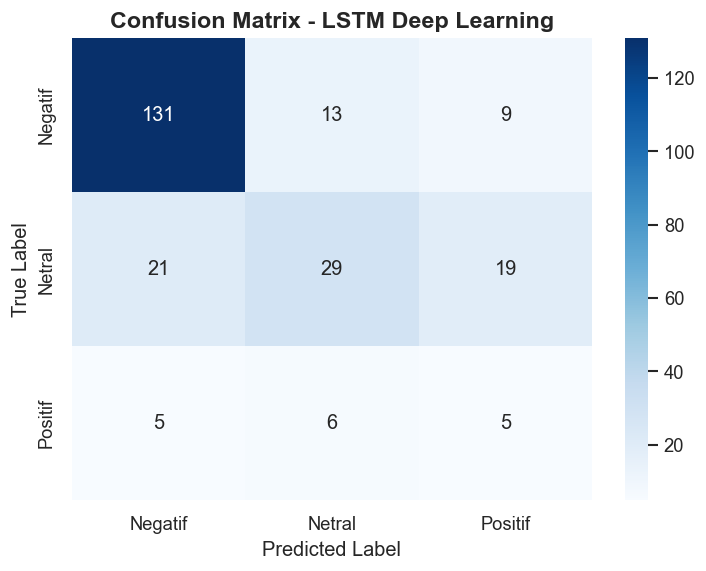

In [8]:
# Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - LSTM Deep Learning', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/dl_confusion_matrix.png', bbox_inches='tight')
plt.show()
